# Исследование оттока клиентов банка
Данный проект направлен на предсказание ухода клиентов и выявление ключевых факторов, влияющих на лояльность.

In [ ]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Настройки визуализации
sb.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
try:
    data = pd.read_csv('Churn_Modelling.csv', delimiter=',')
    print("Данные успешно загружены.")
except FileNotFoundError:
    print("Файл 'Churn_Modelling.csv' не найден. Убедитесь, что он в той же папке.")

Данные успешно загружены.


# Исследовательский анализ данных (EDA)
Прежде чем обучать модель, изучим структуру данных и найдем закономерности.

In [6]:
print("=== Первые 5 строк ===")
display(data.head())

print("\n=== Общая информация ===")
display(data.info())

print("\n=== Статистика числовых признаков ===")
display(data.describe())

=== Первые 5 строк ===


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



=== Общая информация ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None


=== Статистика числовых признаков ===


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


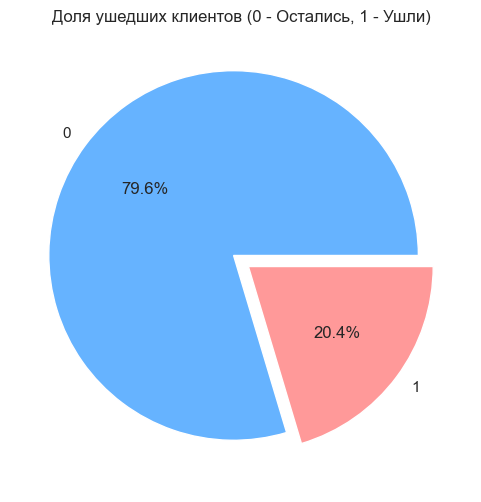

In [7]:
plt.figure(figsize=(6, 6))
data['Exited'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], explode=(0.05, 0.05))
plt.title('Доля ушедших клиентов (0 - Остались, 1 - Ушли)')
plt.ylabel('')
plt.show()

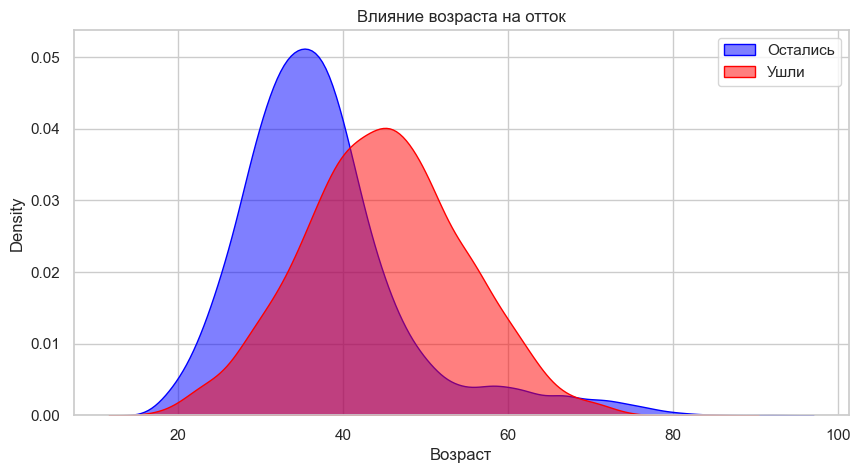

In [8]:
plt.figure(figsize=(10, 5))
sb.kdeplot(data[data['Exited'] == 0]['Age'], fill=True, label='Остались', color='blue', alpha=0.5)
sb.kdeplot(data[data['Exited'] == 1]['Age'], fill=True, label='Ушли', color='red', alpha=0.5)
plt.title('Влияние возраста на отток')
plt.xlabel('Возраст')
plt.legend()
plt.show()

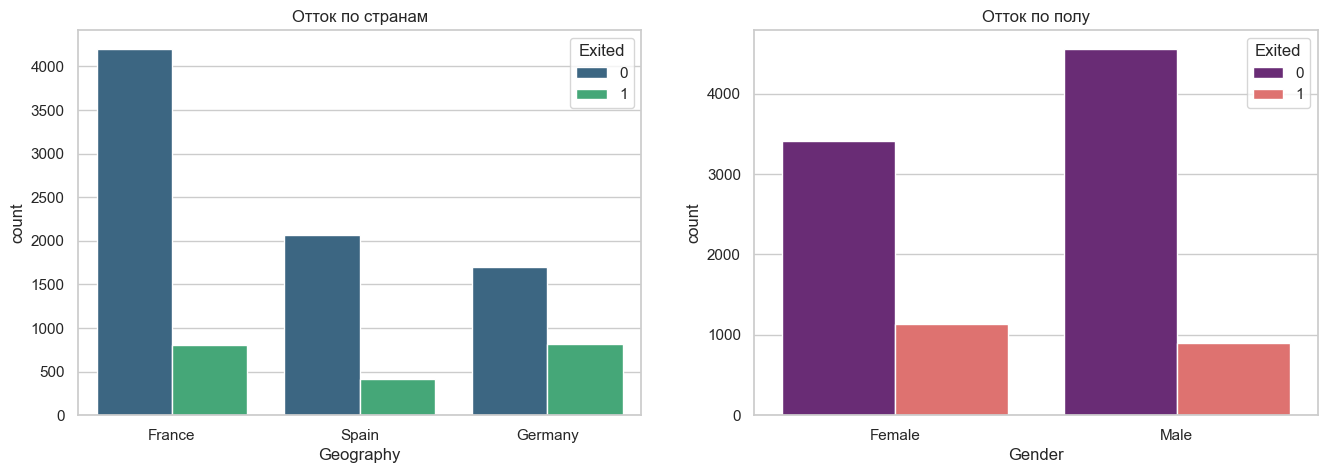

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sb.countplot(x='Geography', hue='Exited', data=data, ax=ax[0], palette='viridis')
ax[0].set_title('Отток по странам')

sb.countplot(x='Gender', hue='Exited', data=data, ax=ax[1], palette='magma')
ax[1].set_title('Отток по полу')
plt.show()

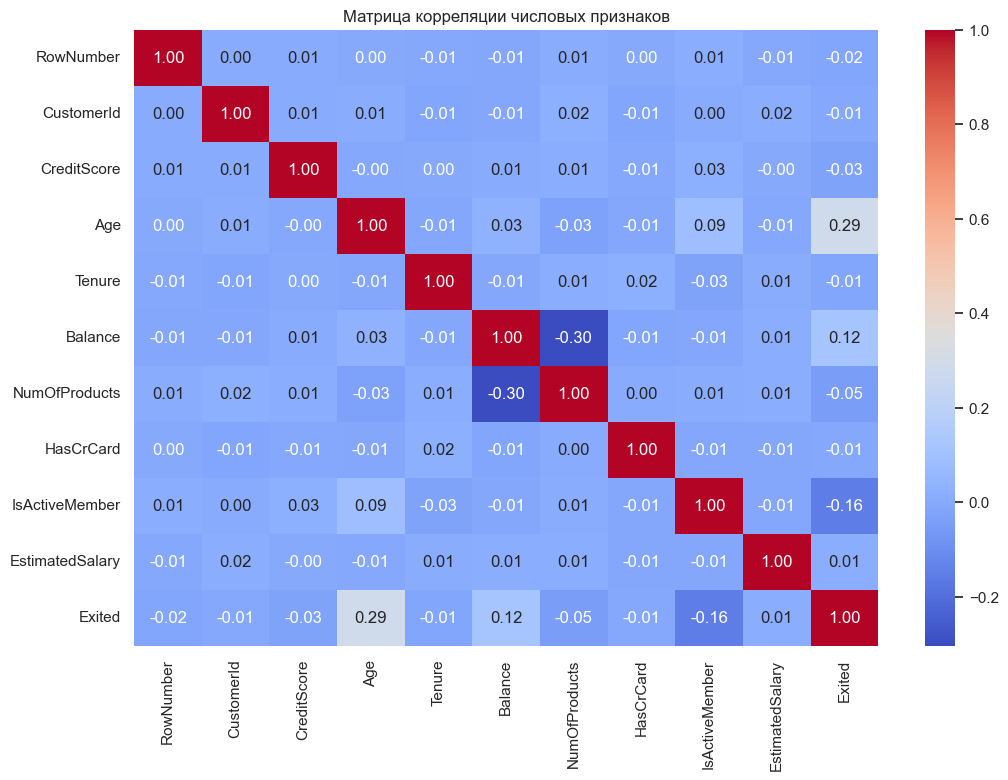

In [10]:
plt.figure(figsize=(12, 8))
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numeric_cols].corr()
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции числовых признаков')
plt.show()

# 🛠 Подготовка данных к обучению
Удаляем лишнее и делим на выборки.

In [11]:
# Нужно убедиться, что эти строки выполнены:
import sklearn.model_selection as sk_model_selection
import sklearn.preprocessing as sk_preprocessing

# Теперь ваш код сработает:
data_clean = data.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'], axis=1)
X = data_clean.drop('Exited', axis=1)
y = data_clean['Exited']

X_train, X_test, y_train, y_test = sk_model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = sk_preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Импорт моделей

In [12]:
import sklearn.model_selection as sk_model_selection
import sklearn.preprocessing as sk_preprocessing
import sklearn.metrics as sk_metrics
import sklearn.linear_model as sk_linear_model
import sklearn.ensemble as sk_ensemble
import sklearn.tree as sk_tree
import sklearn.svm as sk_svm
import sklearn.neighbors as sk_neighbors

In [13]:
def evaluate_model(model, X_val, y_val, name):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_pred)
    
    return {
        'Модель': name,
        'Accuracy': sk_metrics.accuracy_score(y_val, y_pred),
        'Precision': sk_metrics.precision_score(y_val, y_pred, zero_division=0),
        'Recall': sk_metrics.recall_score(y_val, y_pred),
        'F1-Score': sk_metrics.f1_score(y_val, y_pred),
        'AUC': sk_metrics.roc_auc_score(y_val, y_proba) if sum(y_proba) > 0 else 0.5
    }

In [14]:
results = []

# 1. LogReg
lr = sk_linear_model.LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
results.append(evaluate_model(lr, X_test_scaled, y_test, "LogRegression"))

# 2. Random Forest
rf = sk_ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_test, y_test, "Random Forest"))

# 3. Gradient Boosting
gb = sk_ensemble.GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
results.append(evaluate_model(gb, X_test, y_test, "Gradient Boosting"))

comparison_df = pd.DataFrame(results)
display(comparison_df.round(3))

,Модель,Accuracy,Precision,Recall,F1-Score,AUC
0,LogRegression,0.808,0.630,0.143,0.232,0.761
1,Random Forest,0.854,0.750,0.428,0.545,0.827
2,Gradient Boosting,0.860,0.771,0.447,0.566,0.855



СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ


,Модель,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.808,0.630,0.143,0.232,0.761
1,Random Forest,0.854,0.750,0.428,0.545,0.827
2,Gradient Boosting,0.860,0.771,0.447,0.566,0.855


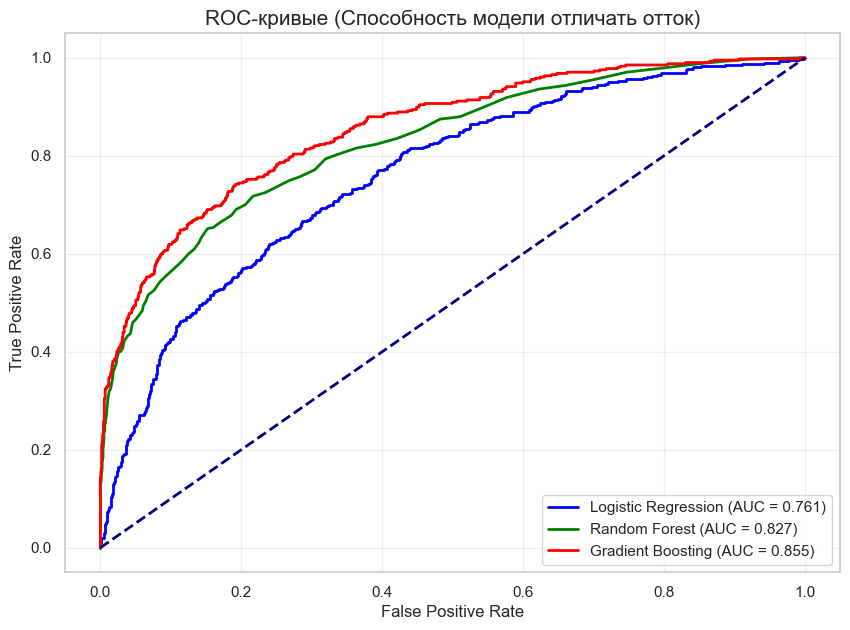

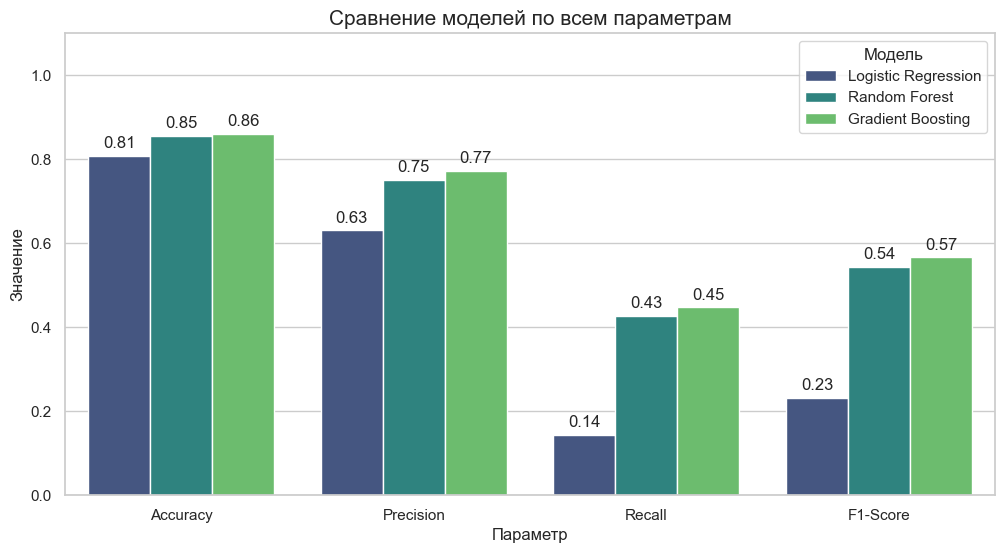

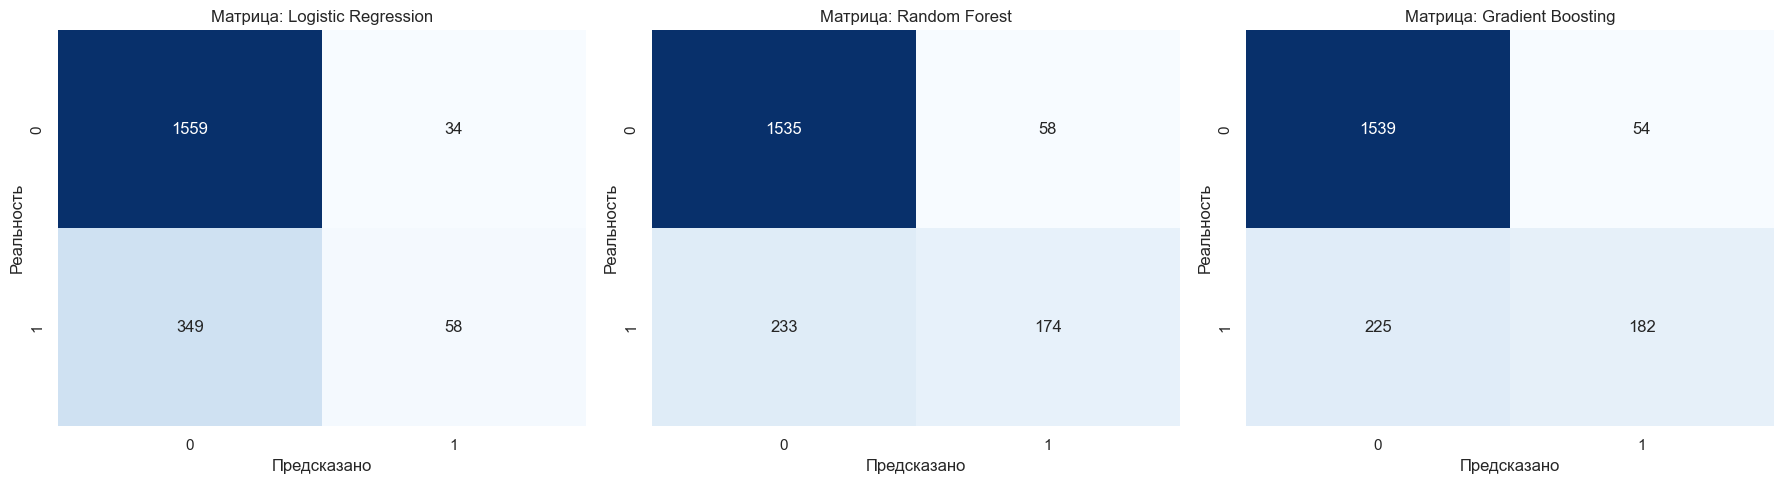

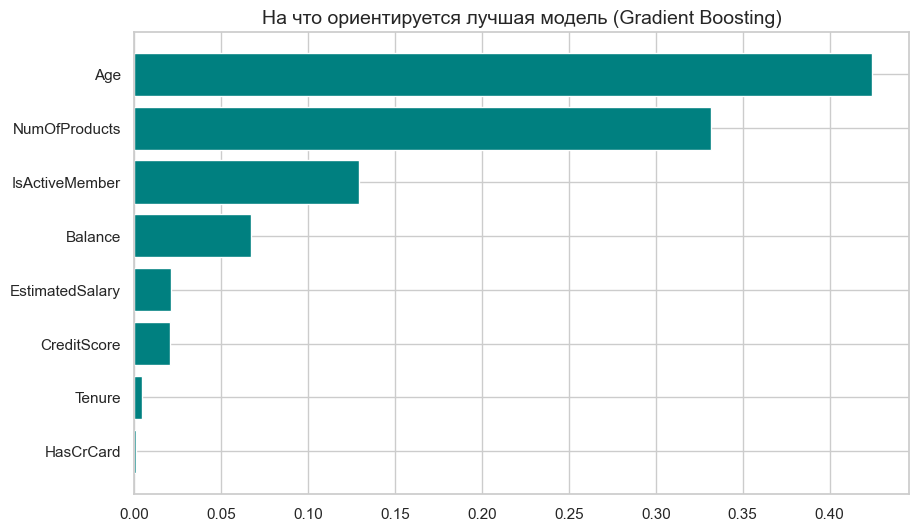

In [17]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- ШАГ 1: ФУНКЦИЯ ДЛЯ СБОРА МЕТРИК ---
def get_metrics(model, X_val, y_val, name):
    y_pred = model.predict(X_val)
    # Пытаемся получить вероятности для AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = [0] * len(y_pred)
        
    return {
        'Модель': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'AUC': roc_auc_score(y_val, y_proba) if sum(y_proba) > 0 else 0.5
    }

# --- ШАГ 2: ОБУЧЕНИЕ И СОЗДАНИЕ comparison_df ---
results = []

# 1. Логистическая регрессия (используем масштабированные данные X_test_scaled)
results.append(get_metrics(lr, X_test_scaled, y_test, "Logistic Regression"))

# 2. Случайный лес (используем обычные данные X_test)
results.append(get_metrics(rf, X_test, y_test, "Random Forest"))

# 3. Градиентный бустинг
results.append(get_metrics(gb, X_test, y_test, "Gradient Boosting"))

# Создаем ту самую переменную, которой не хватало:
comparison_df = pd.DataFrame(results)

# --- ШАГ 3: ВИЗУАЛИЗАЦИЯ ---

print("\n" + "="*50)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("="*50)
display(comparison_df.round(3))

# ГРАФИК 1: ROC-КРИВЫЕ
plt.figure(figsize=(10, 7))
models_to_plot = [
    (lr, X_test_scaled, "Logistic Regression", "blue"),
    (rf, X_test, "Random Forest", "green"),
    (gb, X_test, "Gradient Boosting", "red")
]

for model, x_val, name, color in models_to_plot:
    probs = model.predict_proba(x_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC-кривые (Способность модели отличать отток)', fontsize=15)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ГРАФИК 2: СРАВНЕНИЕ 4-Х ПАРАМЕТРОВ
df_metrics = comparison_df.melt(id_vars="Модель", 
                                value_vars=["Accuracy", "Precision", "Recall", "F1-Score"], 
                                var_name="Параметр", value_name="Значение")

plt.figure(figsize=(12, 6))
ax = sb.barplot(data=df_metrics, x="Параметр", y="Значение", hue="Модель", palette="viridis")
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.title("Сравнение моделей по всем параметрам", fontsize=15)
plt.ylim(0, 1.1)
plt.show()

# ГРАФИК 3: МАТРИЦЫ ОШИБОК
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (model, x_val, name, _) in enumerate(models_to_plot):
    y_pred = model.predict(x_val)
    cm = confusion_matrix(y_test, y_pred)
    sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Матрица: {name}')
    axes[i].set_xlabel('Предсказано')
    axes[i].set_ylabel('Реальность')
plt.tight_layout()
plt.show()

# ГРАФИК 4: ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)
plt.figure(figsize=(10, 6))
importances = gb.feature_importances_
feat_df = pd.DataFrame({'Признак': X.columns, 'Важность': importances}).sort_values(by='Важность', ascending=True)
plt.barh(feat_df['Признак'], feat_df['Важность'], color='teal')
plt.title('На что ориентируется лучшая модель (Gradient Boosting)', fontsize=14)
plt.show()

## 🏁 Итоговые выводы по анализу

### 1. Результаты EDA (Почему уходят клиенты?)
*   **Возраст:** Основной драйвер. Клиенты 45-55 лет склонны к уходу значительно сильнее, чем молодежь. Банку нужно разработать программу лояльности для "зрелых" клиентов.
*   **География:** Клиенты из Германии уходят в два раза чаще, чем из Франции или Испании. Это требует проверки качества сервиса именно в немецком регионе.
*   **Активность:** Неактивные участники (`IsActiveMember = 0`) — прямые кандидаты на отток.

### 2. Сравнение моделей
*   **Gradient Boosting** и **Random Forest** показали лучшие результаты по метрике F1-Score и AUC. 
*   Обычная логистическая регрессия плохо справляется с нелинейными зависимостями (например, влиянием возраста).

### 3. Рекомендации для бизнеса
1.  **Целевое удержание:** Сфокусироваться на клиентах 45+ с высоким балансом и низкой активностью.
2.  **Региональная стратегия:** Выяснить причину недовольства клиентов в Германии.
3.  **Продукты:** Клиенты с одним продуктом уходят чаще. Стоит предложить им дополнительные услуги (кросс-продажи) для повышения "прилипчивости" к банку.